# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
import unicodedata
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
import community
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
nltk.download('punkt_tab')
from tqdm import tqdm
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata

In [ ]:
carpeta = 'C:/Users/Desktop/caso_04'
textos_sargento = []
textos_soldado = []
textos_mayor = []
textos_teniente_coronel = []
textos_capitan = []
textos_coronel= []
textos_subintendente_jefe = []
textos_otros = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()

        # normalizar: minúsculas, quitar tildes y signos
        archivo_norm = unidecode(archivo.lower())
        archivo_norm = archivo_norm.replace(',', '').replace('-', ' ').replace('_', ' ')

        if 'mayor' in archivo_norm:
            textos_mayor.append((archivo, contenido))
        if 'sargento' in archivo_norm:
            textos_sargento.append((archivo, contenido))
        if 'soldado' in archivo_norm:
            textos_soldado.append((archivo, contenido))
        if 'capitan' in archivo_norm or 'teniente capitan' in archivo_norm:
            textos_capitan.append((archivo, contenido))
        elif 'teniente coronel' in archivo_norm:
            textos_teniente_coronel.append((archivo, contenido))
        elif 'coronel' in archivo_norm and 'mayor coronel' not in archivo_norm:
            textos_coronel.append((archivo, contenido))
        if 'subintendente jefe' in archivo_norm:
            textos_subintendente_jefe.append((archivo, contenido))

        else:
            textos_otros.append((archivo, contenido))

def unificar_riosucio(texto):
    return re.sub(r"\br[ií]o?\s+sucio\b", "riosucio", texto, flags=re.IGNORECASE)

texto_sargento = unificar_riosucio(' '.join([contenido for _, contenido in textos_sargento]))
texto_soldado = unificar_riosucio(' '.join([contenido for _, contenido in textos_soldado]))
texto_mayor = unificar_riosucio(' '.join([contenido for _, contenido in textos_mayor]))
texto_teniente_coronel = unificar_riosucio(' '.join([contenido for _, contenido in textos_teniente_coronel]))
texto_capitan = unificar_riosucio(' '.join([contenido for _, contenido in textos_capitan]))
texto_subintendente = unificar_riosucio(' '.join([contenido for _, contenido in textos_subintendente_jefe]))
texto_coronel = unificar_riosucio(' '.join([contenido for _, contenido in textos_coronel]))

print(f"Archivos de sargento: {len(textos_sargento)}")
print(f"Archivos de soldado: {len(textos_soldado)}")
print(f"Archivos de mayor: {len(textos_mayor)}")
print(f"Archivos de teniente coronel: {len(textos_teniente_coronel)}")
print(f"Archivos de coronel: {len(textos_coronel)}")
print(f"Archivos de capitan: {len(textos_capitan)}")
print(f"Archivos de subintendente jefe: {len(textos_subintendente_jefe)}")


Archivos de sargento: 16
Archivos de soldado: 24
Archivos de mayor: 16
Archivos de teniente coronel: 5
Archivos de coronel: 4
Archivos de capitan: 4
Archivos de subintendente jefe: 2


In [4]:
#FUNCIONES DE LIMPIEZA DE TEXTO

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    tokens = word_tokenize(texto)
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)

def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas

def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}  # palabras que no queremos eliminar como UP(unión patriótica) y fe
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado


def aplicar_lematizacion(texto, lematizaciones):
    palabras = texto.split()
    palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
    return ' '.join(palabras_lematizadas)


In [ ]:
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

# --- Aplicar la lematización a cada texto
textos = {
    'sargento': texto_sargento,
    'soldado': texto_soldado,
    'mayor': texto_mayor,
    'teniente coronel': texto_teniente_coronel,
    'capitan': texto_capitan,
    'coronel' :texto_coronel,
    'subintendente jefe': texto_subintendente
}

textos_lematizados = {}

for nombre, texto in textos.items():
    textos_lematizados[nombre] = aplicar_lematizacion(texto, lematizaciones)

texto_sargento_lem = textos_lematizados['sargento']
texto_soldado_lem = textos_lematizados['soldado']
texto_mayor_lem = textos_lematizados['mayor']
texto_teniente_lem = textos_lematizados['teniente coronel']
texto_capitan_lem = textos_lematizados['capitan']
texto_subintendente_jefe_lem = textos_lematizados['subintendente jefe']
texto_coronel_lem = textos_lematizados['coronel']

#Eliminar palabras cortas:
texto_sargento_final = eliminar_palabras_cortas(texto_sargento_lem)
texto_soldado_final = eliminar_palabras_cortas(texto_soldado_lem)
texto_mayor_final = eliminar_palabras_cortas(texto_mayor_lem)
texto_teniente_final = eliminar_palabras_cortas(texto_teniente_lem)
texto_capitan_final = eliminar_palabras_cortas(texto_capitan_lem)
texto_subintendente_jefe_final = eliminar_palabras_cortas(texto_subintendente_jefe_lem)
texto_coronel_final = eliminar_palabras_cortas(texto_coronel_lem)


textos = {
    "sargento": texto_sargento_final,
    "soldado": texto_soldado_final,
    "mayor": texto_mayor_final,
    "teniente coronel": texto_teniente_final,
    "capitan": texto_capitan_final,
    "subintendente jefe": texto_subintendente_jefe_final,
    "coronel" : texto_coronel_final}

#Tokenizar:
tokens_dict = {}
for nombre, texto in textos.items():
    tokens = nltk.word_tokenize(texto, language="spanish")
    tokens_dict[nombre] = tokens


# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# palabras que NO deben lematizarse
excepciones = {"voluntaria", "soldado"}
nlp = spacy.load("es_core_news_md", disable=["parser", "ner"])

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser", "ner"])
        for tok_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if tok_original.lower() in excepciones:
                lemas.append(tok_original.lower())
            else:
                lemas.append(token_spacy.lemma_)
    return lemas

lemas_dict = {}
for nombre, tokens in tokens_dict.items():
    print(f"\n Texto: {nombre} ({len(tokens)} tokens)")
    lemas_dict[nombre] = lematizar_en_bloques(tokens, bloque_size=10000)

In [ ]:
# Construir textos_lemas sin pasar por archivos
textos_lemas = {
    nombre: " ".join(lemas_dict[nombre])
    for nombre in ["sargento", "soldado", "mayor", "teniente coronel", "capitan", "subintendente jefe", "coronel"]}

# Lematizaciones personalizadas por caso:
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_04.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()

textos_finales_dicc = {}
for nombre, texto in textos_lemas.items():
    palabras = texto.split()

    texto_lemas_dicc = []
    for palabra in palabras:
        if palabra in lematizaciones2:
            if lematizaciones2[palabra] != "NA":
                texto_lemas_dicc.append(lematizaciones2[palabra])
            # si es "NA", no se agrega nada (se elimina)
        else:
            texto_lemas_dicc.append(palabra)

    texto_final = " ".join(texto_lemas_dicc)
    textos_finales_dicc[nombre] = texto_final



# **Generar skipgramas**

In [ ]:
def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# ---------------------------- stopwords ---------------------------------
stop_words = set(stopwords.words('spanish'))

archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'
with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for linea in f:
        word = linea.strip()
        stop_words.add(word)
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))

ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"
lemas_set = set()
lematizaciones_final = {}
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ":" in linea:
            palabra, lema = linea.strip().split(":", 1)
            lemas_set.add(palabra.strip())
            lematizaciones_final[normalizar(palabra.strip())] = normalizar(lema.strip())

filtradas = [p for p in palabras_no_validas if p not in lemas_set]


textos_finales_limpios = {}
for nombre, texto_final in textos_finales_dicc.items():
    textos_finales_limpios[nombre] = limpiar_texto(texto_final)

# -------------------------- Lematizar ---------------------------------------------
textos_lema_dicc = {}
for nombre, texto_final_limpio in textos_finales_limpios.items():
    palabras = texto_final_limpio.split()
    palabras_lematizadas = [lematizaciones_final.get(palabra, palabra) for palabra in palabras]
    textos_lema_dicc[nombre] = " ".join(palabras_lematizadas)


textos_filtrados = {}
for nombre, texto_lema in textos_lema_dicc.items():
    palabras = texto_lema.split()
    textos_filtrados[nombre] = " ".join([p for p in palabras if p not in filtradas])

# ----------------------- Generar skipgramas ------------------------------------------
textos_skipgramas = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)
    tokens_filtrados = [t for t in tokens if frec[t] > 1]
    texto_dep = " ".join(tokens_filtrados)
    skipgramas = generar_skipgramas(texto_dep, 2, 2)
    textos_skipgramas[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": skipgramas}

In [ ]:
##eliminar bucles en skipgramas
textos_skipgramas_filtrados = {}

for nombre, datos in textos_skipgramas.items():
    skipgramas = datos["skipgramas"]

    # Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    # Conservar solo los skipgramas con frecuencia > 1
    skipgramas_filtrados = [b for b, f in conteo.items() if f > 1]
    textos_skipgramas_filtrados[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#calcular frecuencias
tablas_frecuencias = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    conteo_str = {' '.join(k): v for k, v in conteo.items() if v > 1}
    df_top = pd.DataFrame(Counter(conteo_str).most_common(10), columns=["Skipgrama", "Frecuencia"])
    tablas_frecuencias[nombre] = df_top

    print(f"\nTop 10 skipgramas en '{nombre}':")
    display(df_top)


Top 10 skipgramas en 'sargento':


,Skipgrama,Frecuencia
0,comandante batallon,553
1,brigada movil,416
2,comandante compania,354
3,comandante peloton,341
4,grupo especial,285
5,resultar operacion,268
6,compania peloton,262
7,comandante brigada,248
8,peloton compania,245
9,batallon comandante,213



Top 10 skipgramas en 'soldado':


,Skipgrama,Frecuencia
0,comandante batallon,557
1,grupo especial,557
2,comandante compania,517
3,batallon compania,371
4,ministerio publico,330
5,comandante peloton,306
6,compania brasil,284
7,compania canada,277
8,compania comandante,274
9,soldado profesional,266



Top 10 skipgramas en 'mayor':


...

,Skipgrama,Frecuencia
0,grupo especial,222
1,comandante batallon,145
2,comandante compania,142
3,brigada movil,100
4,compania peloton,90
5,resultar operacion,88
6,especial grupo,71
7,peloton compania,71
8,comandante peloton,67
9,capitan compania,64



Top 10 skipgramas en 'subintendente jefe':


,Skipgrama,Frecuencia
0,policia carretera,62
1,policia nacional,41
2,ministerio publico,29
3,guillermo chavez,28
4,estacion policia,28
5,tarjeta profesional,26
6,entregar persona,25
7,persona entregar,20
8,dato correcto,20
9,version voluntaria,18



Top 10 skipgramas en 'coronel':


,Skipgrama,Frecuencia
0,brigada movil,203
1,comandante batallon,181
2,comandante brigada,165
3,batallon contraguerrilla,112
4,resultar operacion,110
5,batallon brigada,93
6,mision tactico,91
7,brigada batallon,82
8,capitan romero,76
9,investigacion disciplinaria,74


# **ANÁLISIS DESCRIPTIVO**

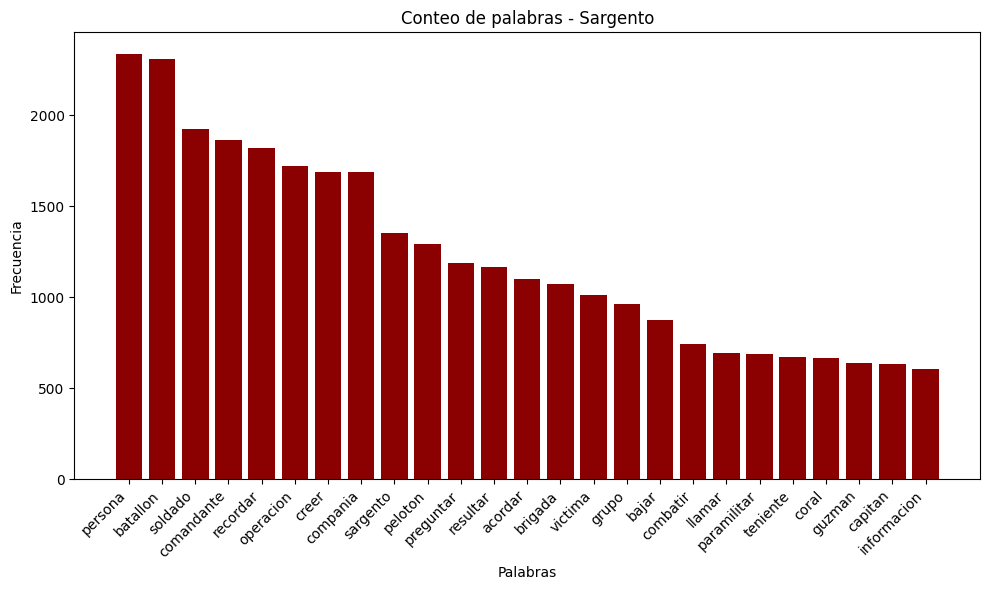

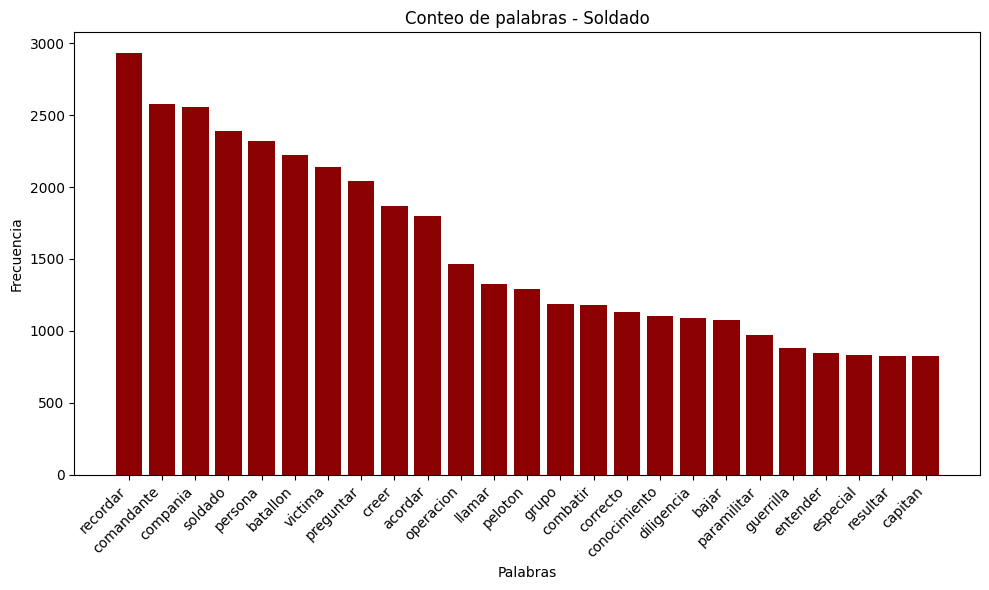

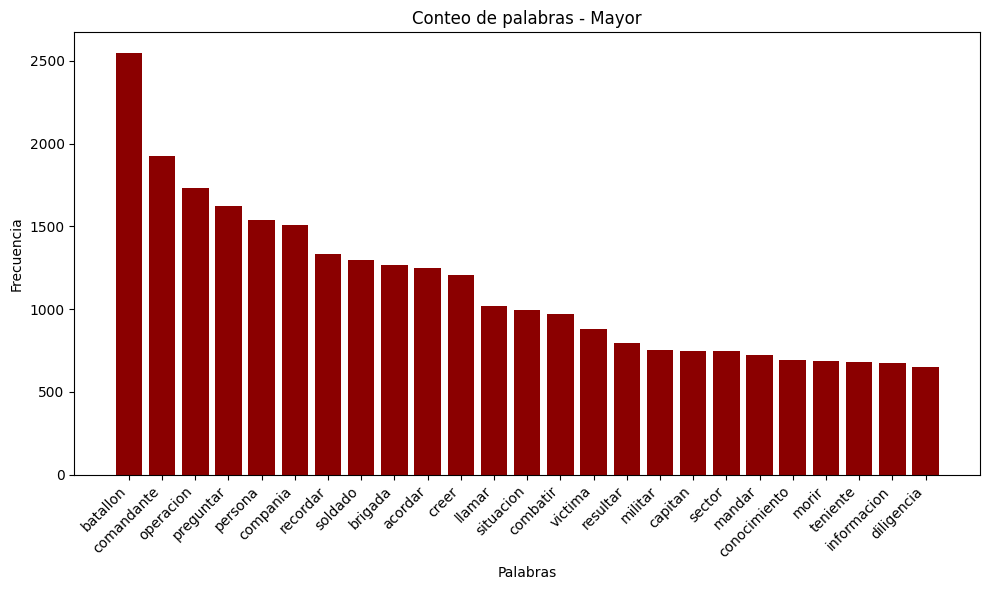

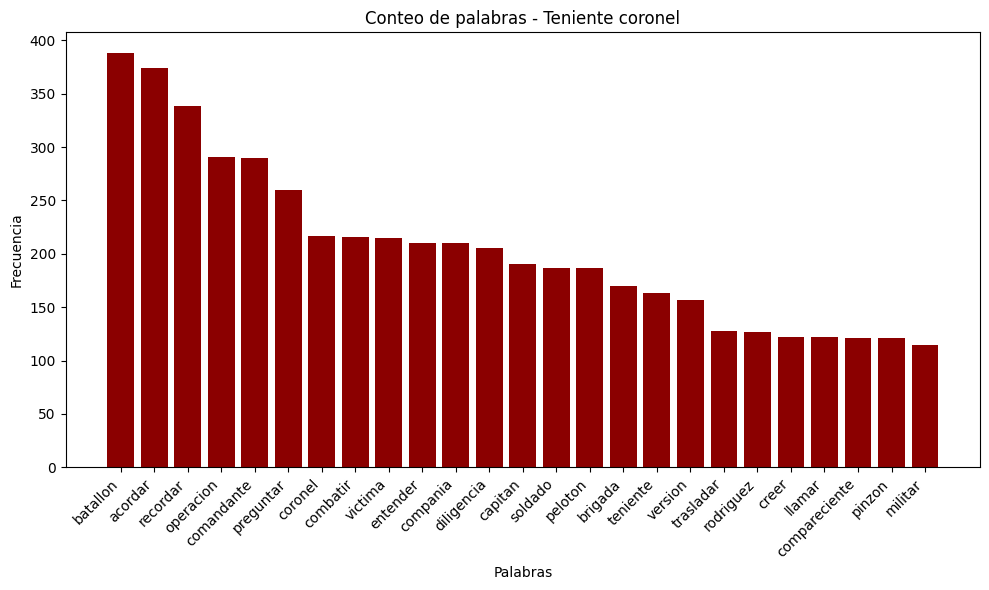

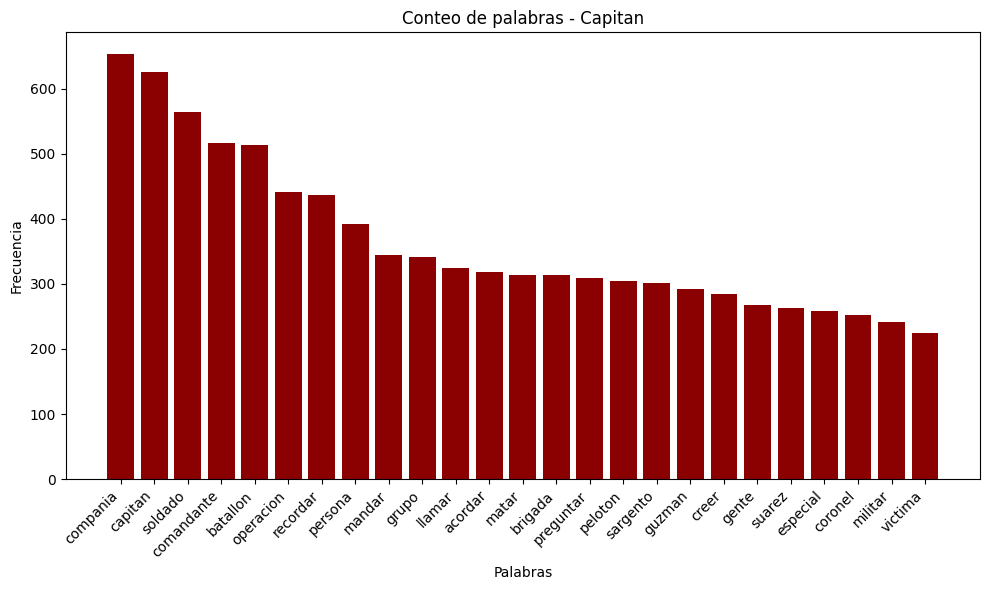

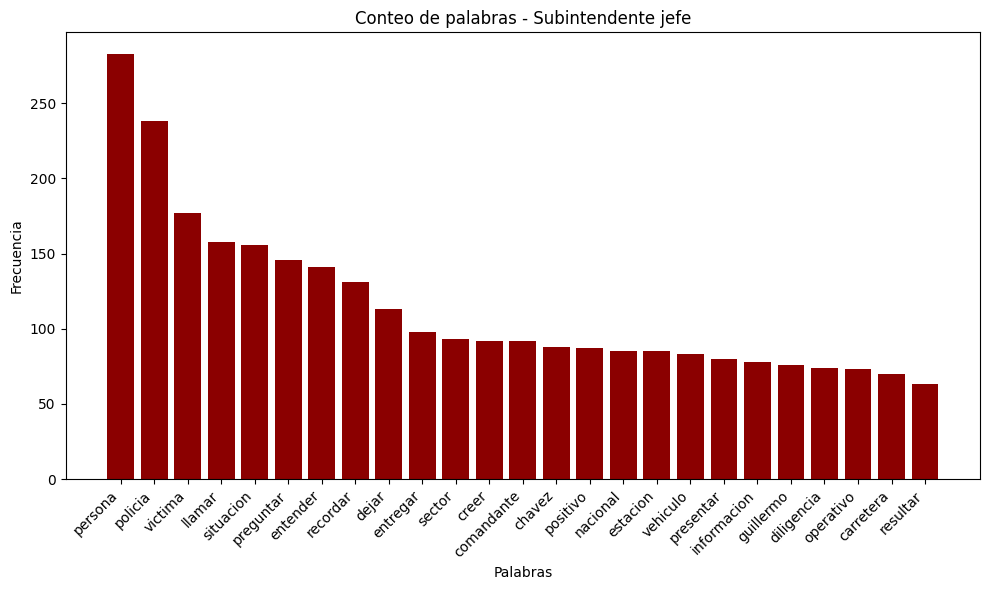

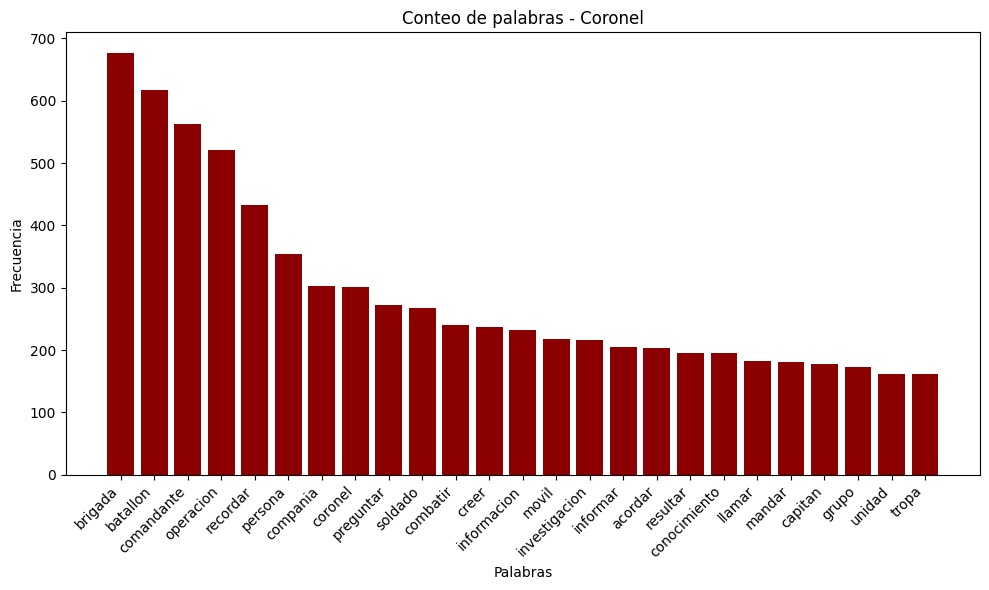

In [ ]:
#Distribucion de freq de términos:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(25)
    palabras, frecuencias = zip(*palabras_repetidas)

    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color="darkred")
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(f"Conteo de palabras - {nombre.capitalize()}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
##Frecuencia de palabras por subanálisis:
tablas_frecuencias = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(15)

    tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
    tablas_frecuencias[nombre] = tabla_frecuencias

    print(f"\n Frecuencias para: {nombre}")
    print(tabla_frecuencias)

tabla_final = pd.concat(tablas_frecuencias, names=['Grupo']).reset_index(level=0)
tabla_final.reset_index(drop=True, inplace=True)


 Frecuencias para: sargento
       Palabra  Frecuencia
0      persona        2338
1     batallon        2308
2      soldado        1923
3   comandante        1861
4     recordar        1819
5    operacion        1722
6        creer        1690
7     compania        1685
8     sargento        1354
9      peloton        1294
10   preguntar        1190
11    resultar        1164
12     acordar        1098
13     brigada        1072
14     victima        1010

 Frecuencias para: soldado
       Palabra  Frecuencia
0     recordar        2929
1   comandante        2578
2     compania        2556
3      soldado        2389
4      persona        2322
5     batallon        2224
6      victima        2136
7    preguntar        2045
8        creer        1868
9      acordar        1800
10   operacion        1467
11      llamar        1327
12     peloton        1291
13       grupo        1188
14    combatir        1183

 Frecuencias para: mayor
       Palabra  Frecuencia
0     batallon        2545

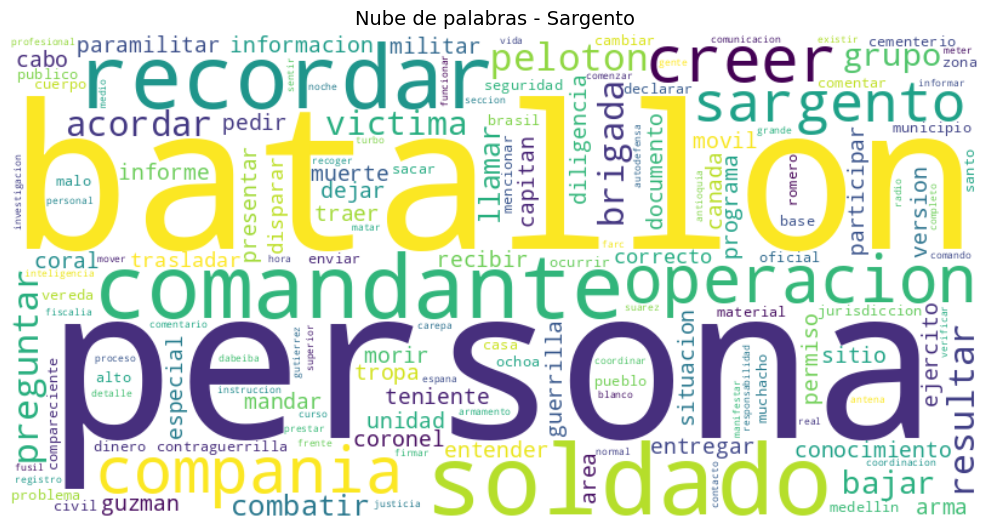

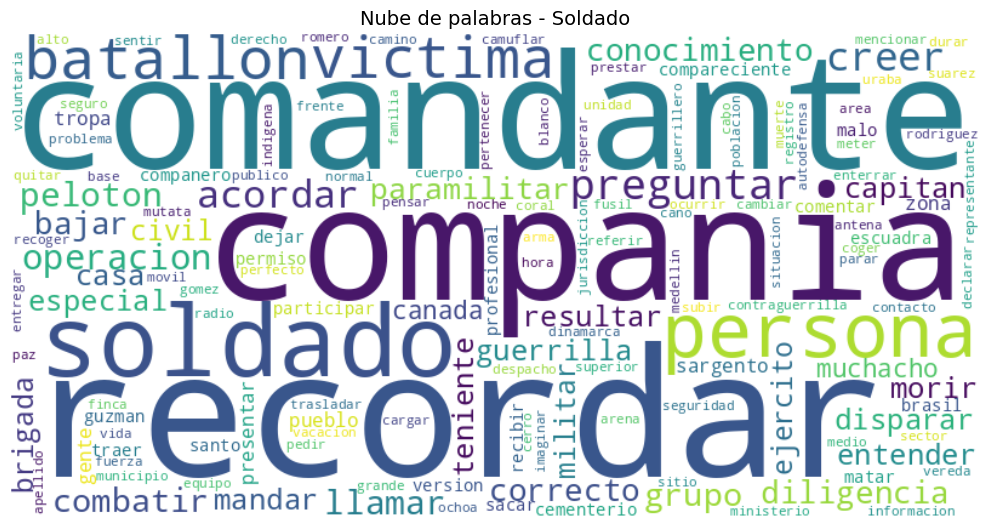

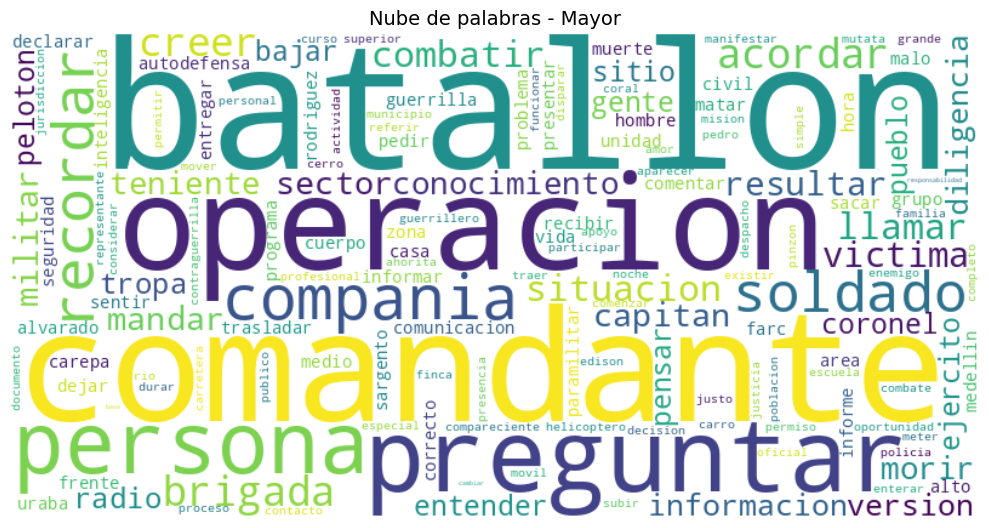

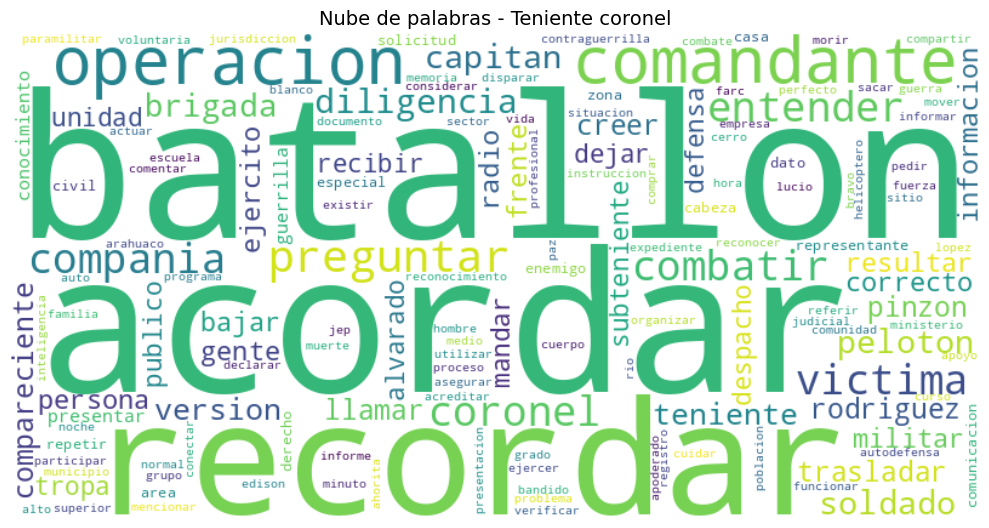

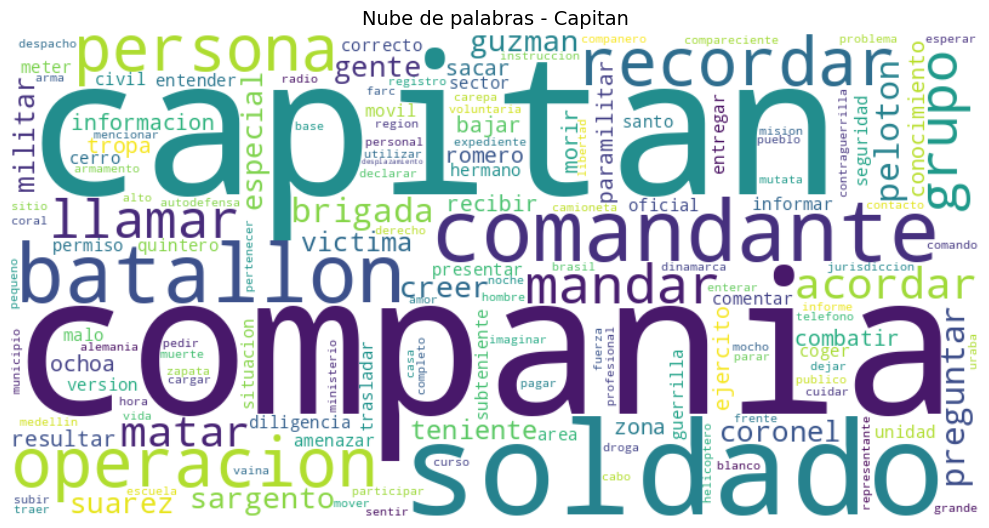

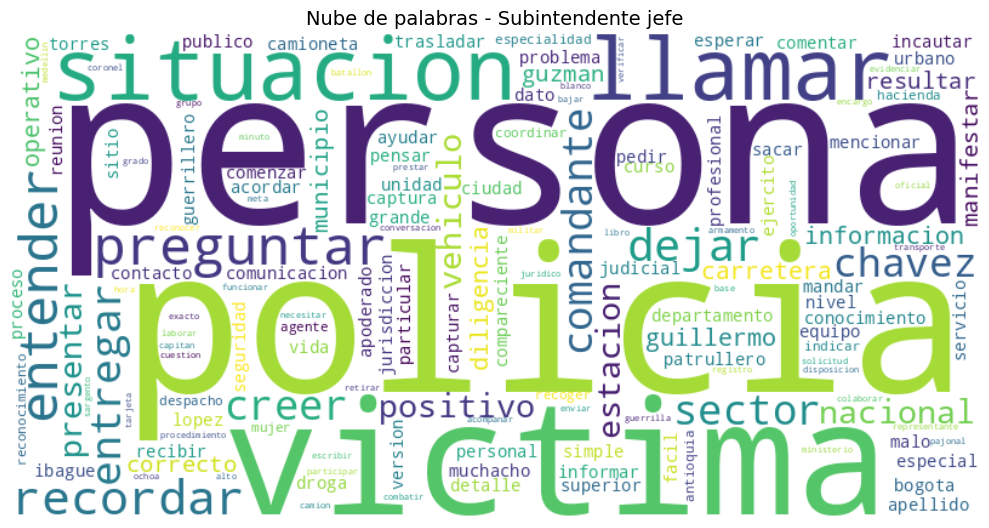

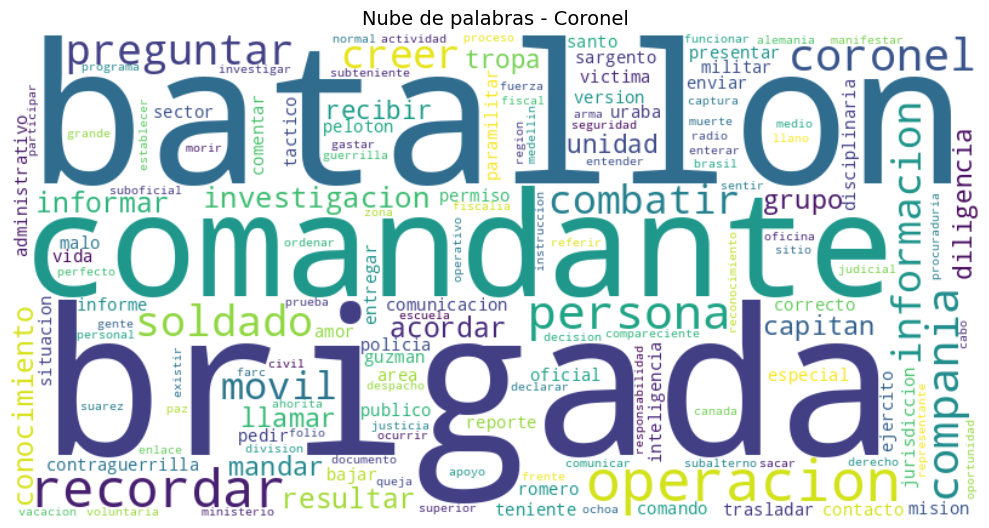

In [ ]:
#  Crear nube de palabras para cada grupo de análisis
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)

    nube = WordCloud(width=800, height=400,
        background_color='white',
        max_words=150
    ).generate_from_frequencies(frecuencia_palabras)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras - {nombre.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()


# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

lexico['Palabra'] = (
    lexico['Palabra'].astype(str).str.lower().str.strip().apply(unidecode).str.replace(r'[^a-zñáéíóúü\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True))

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')


resultados = []
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    # Normalizar
    tokens = [ re.sub(r'\s+', ' ',re.sub(r'[^a-zñáéíóúü\s]', '',
                      unidecode(t.lower().strip())))
        for t in word_tokenize(texto)]

    conteo = Counter({emo: 0 for emo in columnas_emociones})

    for token in tokens:
        if token in emociones:
            for emo, valor in emociones[token].items():
                conteo[emo] += valor

    conteo['Texto'] = nombre
    resultados.append(conteo)

df_emociones = pd.DataFrame(resultados)
df_emociones = df_emociones[['Texto'] + columnas_emociones]

# Traducir nombres de columnas
df_emociones = df_emociones.rename(columns={'Positive': 'Positivo','Negative': 'Negativo','Anger': 'Ira',
    'Anticipation': 'Anticipación','Disgust': 'Disgusto','Fear': 'Miedo','Joy': 'Alegría','Sadness': 'Tristeza',
    'Surprise': 'Sorpresa', 'Trust': 'Confianza'})
print(df_emociones.head())

              Texto  Positivo  Negativo    Ira  Anticipación  Disgusto  Miedo  \
0          sargento     25643     15508  10637          7527      3635  14255   
1           soldado     36209     21930  15068         10523      4939  18906   
2             mayor     27262     16320  10541          8180      4439  15376   
3  teniente coronel      5153      2556   1777          1386       562   2474   
4           capitan      8195      4726   3187          2304      1051   4285   

   Alegría  Tristeza  Sorpresa  Confianza  
0     5264      9511      4043      17565  
1     8002     13888      5355      23435  
2     4874      9872      3913      19191  
3      844      1393       483       3641  
4     1612      2865      1118       5374  


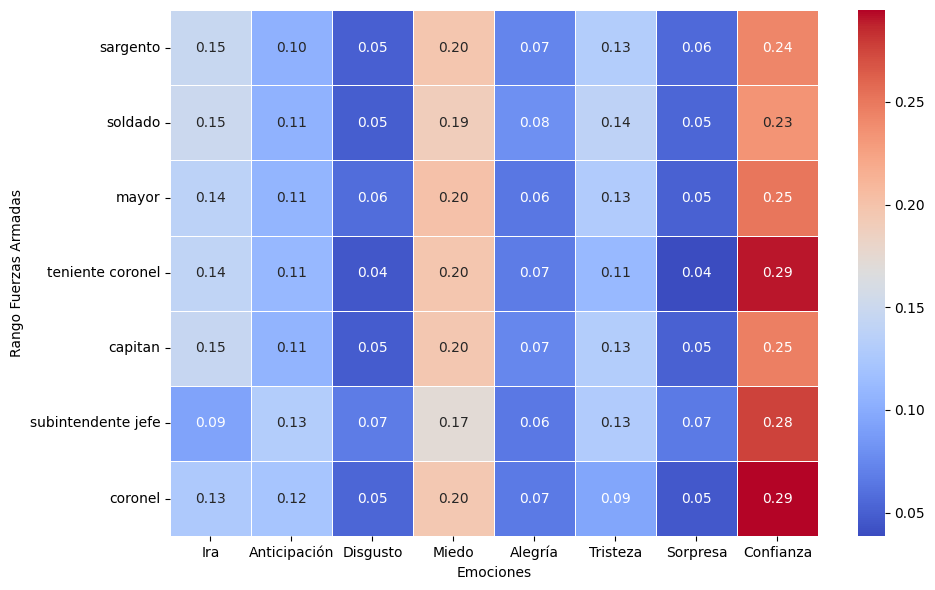

In [ ]:
#Mapa de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)
plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Rango Fuerzas Armadas')
plt.tight_layout()
plt.show()

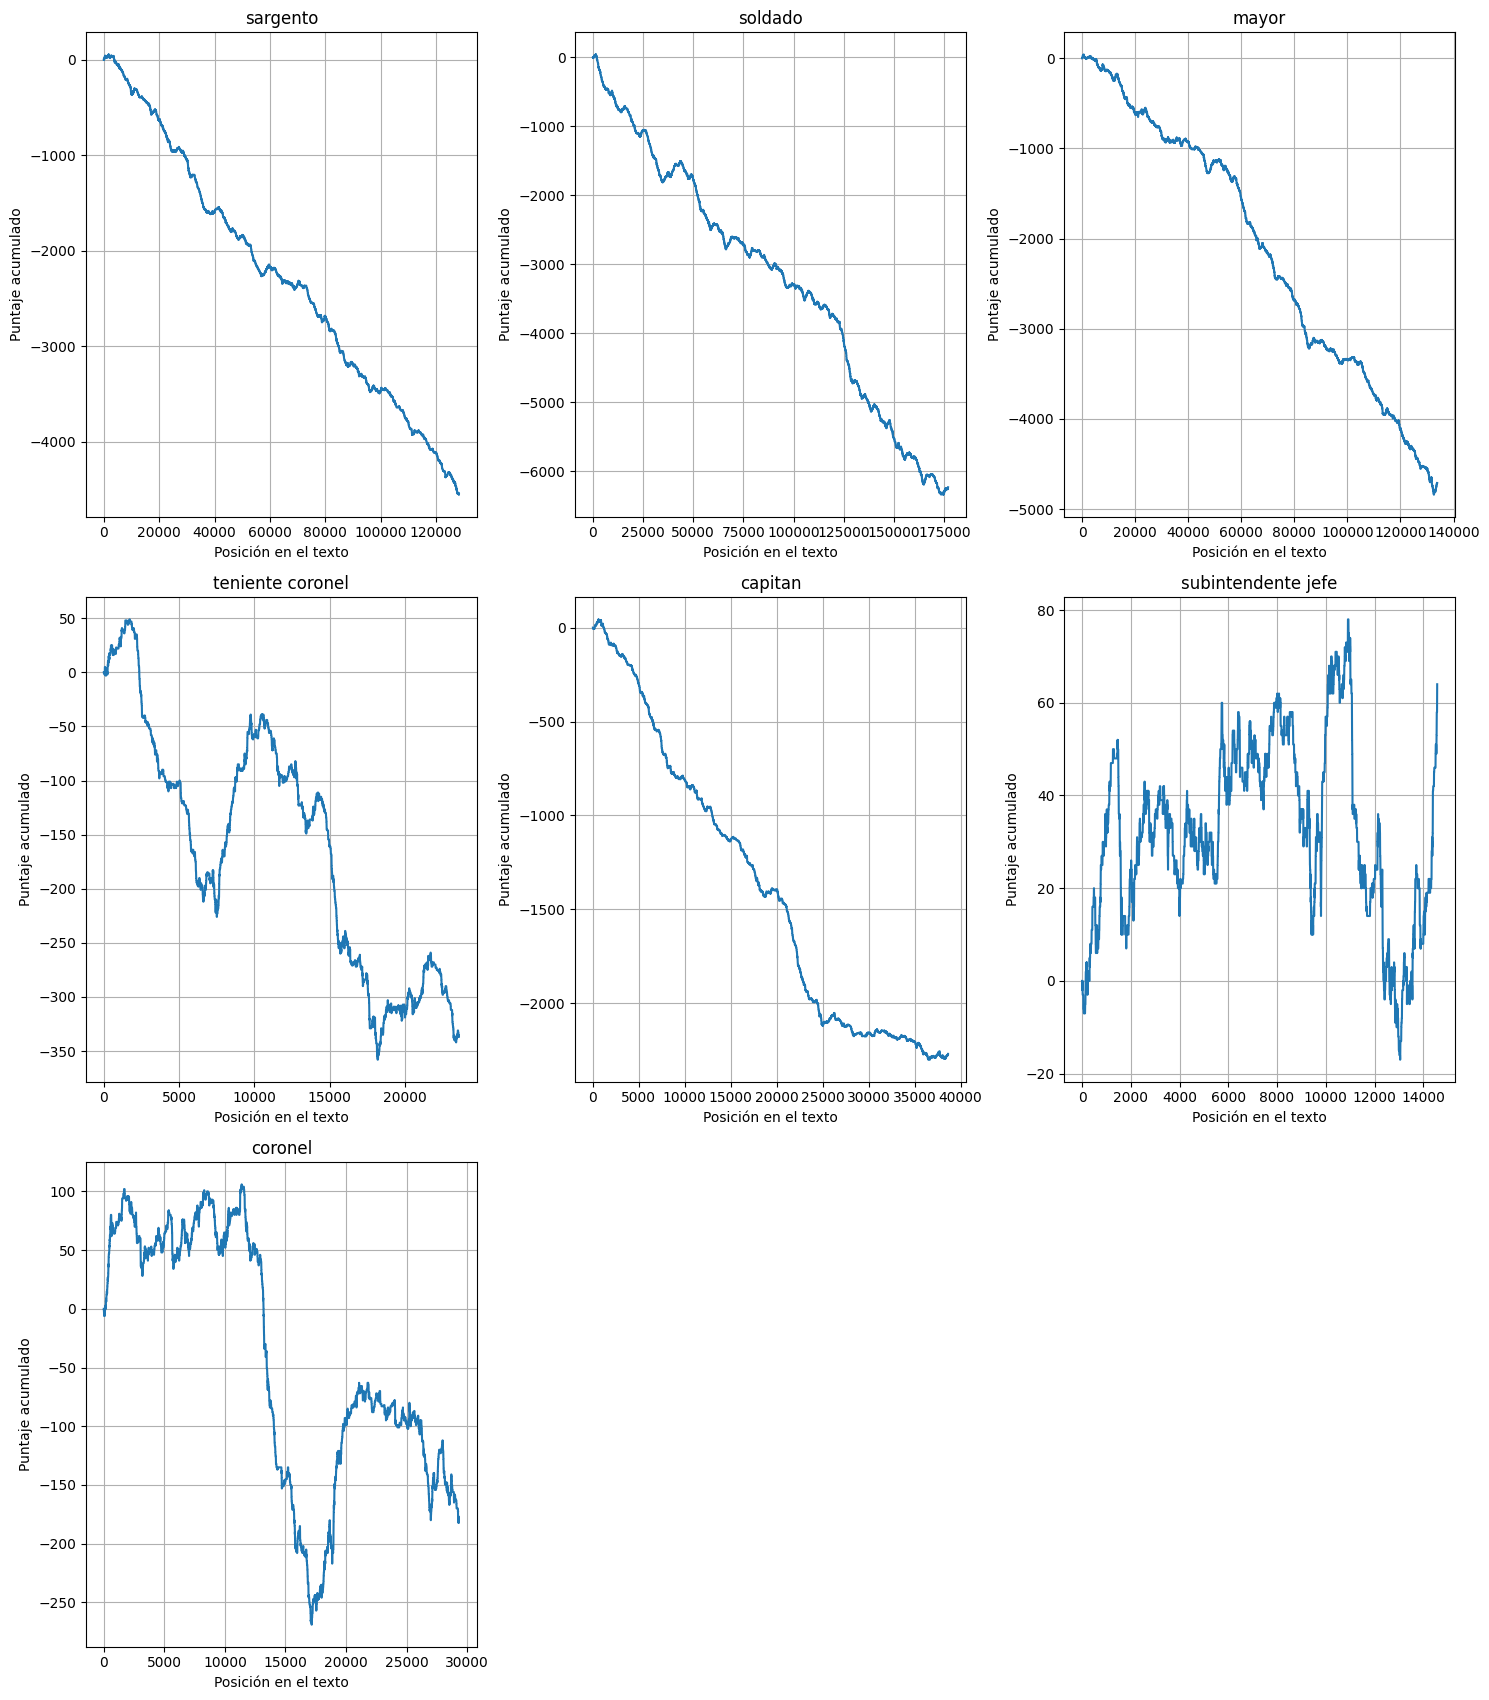

In [ ]:
##Grafico de sentimiento acumulado mediante diccionario AFINN
afinn = pd.read_csv("C:/Users/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")
afinn['palabra'] = afinn['palabra'].str.lower().str.strip()
afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))

tendencias_afinn = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = [
        unidecode(t.lower().strip())
        for t in word_tokenize(texto)]
    puntajes = [
        afinn_dict.get(token, 0)
        for token in tokens]

    df = pd.DataFrame({"palabra": tokens, "puntaje": puntajes})
    df["sentimiento_acumulado"] = df["puntaje"].cumsum()
    tendencias_afinn[nombre] = df

#grafico:
n = len(tendencias_afinn)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 6* nrows))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, tendencias_afinn.items()):
    ax.plot(df.index, df["sentimiento_acumulado"])
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Posición en el texto")
    ax.set_ylabel("Puntaje acumulado")
    ax.grid(True)

for i in range(len(tendencias_afinn), len(axes)):
    axes[i].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



# **RED BASICA**

In [17]:
def get_gigante(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

# ----------------------- Cálculo de métricas --------------------------------------------
redes_metrics = {}
centralidades_por_red = {}
top10_grado_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]

    G = nx.Graph()
    G.add_edges_from(skipgramas)

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = get_gigante(G)

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    # Métricas básicas
    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    # Top 10 por grado
    top10_grado = (
        pd.DataFrame(grados.items(), columns=["nodo", "grado"])
        .sort_values("grado", ascending=False)
        .head(10)
        .assign(porcentaje_grado=lambda x: x["grado"] / (2 * num_aristas))
    )
    top10_grado_por_red[nombre] = top10_grado

    # Centralidades
    nodos = list(G_gigante.nodes())
    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo": nodos,
        "grado": [grados[n] for n in nodos],
        "betweenness": [betweenness[n] for n in nodos],
        "closeness": [closeness[n] for n in nodos],
        "eigenvector": [eigenvector[n] for n in nodos]
    })
    centralidades_por_red[nombre] = df_centralidad

    redes_metrics[nombre] = {
        "num_nodos": num_nodos,
        "num_aristas": num_aristas,
        "densidad": nx.density(G_gigante),
        "grado_promedio": sum(grados.values()) / num_nodos,
        "transitividad_global": nx.transitivity(G_gigante),
        "assortatividad_grado": nx.degree_assortativity_coefficient(G_gigante),
        "diametro": nx.diameter(G_gigante),
        "longitud_media_camino": nx.average_shortest_path_length(G_gigante),
        "betweenness_media": df_centralidad["betweenness"].mean(),
        "betweenness_max": df_centralidad["betweenness"].max(),
        "closeness_media": df_centralidad["closeness"].mean(),
        "eigenvector_media": df_centralidad["eigenvector"].mean(),
        "grado_max": top10_grado["grado"].max(),
        "grado_medio_top10": top10_grado["grado"].mean(),
        "concentracion_top10": top10_grado["grado"].sum() / (2 * num_aristas),
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print("\nMétricas")
print(df_metrics)

Grafo 'sargento': 3253 nodos, 50132 aristas (componente gigante).
Grafo 'soldado': 3596 nodos, 58163 aristas (componente gigante).
Grafo 'mayor': 3545 nodos, 48063 aristas (componente gigante).
Grafo 'teniente coronel': 1472 nodos, 9699 aristas (componente gigante).
Grafo 'capitan': 1897 nodos, 15384 aristas (componente gigante).
Grafo 'subintendente jefe': 1184 nodos, 5835 aristas (componente gigante).
Grafo 'coronel': 1554 nodos, 11416 aristas (componente gigante).

Métricas
                    num_nodos  num_aristas  densidad  grado_promedio  \
sargento                 3253        50132  0.009478       30.822010   
soldado                  3596        58163  0.008998       32.348721   
mayor                    3545        48063  0.007651       27.115938   
teniente coronel         1472         9699  0.008959       13.177989   
capitan                  1897        15384  0.008554       16.219294   
subintendente jefe       1184         5835  0.008332        9.856419   
coronel       

In [18]:
top10_grado_por_red

{'sargento':            nodo  grado  porcentaje_grado
 354     persona   1039          0.010363
 295    batallon    871          0.008687
 331    recordar    869          0.008667
 139       creer    862          0.008597
 557     soldado    846          0.008438
 77     sargento    733          0.007311
 293   operacion    726          0.007241
 247   preguntar    709          0.007071
 442  comandante    652          0.006503
 13      acordar    637          0.006353,
 'soldado':            nodo  grado  porcentaje_grado
 340    recordar   1033          0.008880
 196     persona    966          0.008304
 171     soldado    923          0.007935
 76    preguntar    913          0.007849
 68      victima    880          0.007565
 407       creer    801          0.006886
 49      acordar    761          0.006542
 385  comandante    752          0.006465
 383      llamar    705          0.006061
 321    batallon    685          0.005889,
 'mayor':            nodo  grado  porcentaje_grado


In [28]:
regiones = ["turbo", "apartado","carepa" ,"chigorodo", "mutata", "dabeiba", "carmen_darien", "riosucio", "unguia", "acandi", "pedro_uraba", "tierralta", "valencia"]

##### unificacion de regiones con dos palabras:
def unificar_toponimos(texto):
    texto = texto.lower()
    pares = ["pedro uraba","carmen darien"]
    for p in pares:
        token = p.replace(" ", "_")
        texto = re.sub(rf"\b{re.escape(p)}\b", token, texto)
    return texto

##  Generar los skipgramas con estas modificaciones::
textos_skipgramas2 = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    texto_sin_stopwords = unificar_toponimos(texto_sin_stopwords)

    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)

    tokens_filtrados = [
        t for t in tokens
        if frec[t] > 1 or t in regiones ]
    texto_dep = " ".join(tokens_filtrados)
    skipgramas = generar_skipgramas(texto_dep, 2, 2)
    textos_skipgramas2[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": skipgramas}

textos_skipgramas_filtrados2 = {}

for nombre, datos in textos_skipgramas2.items():
    skipgramas = datos["skipgramas"]

    # Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    skipgramas_filtrados = [
        b for b, f in conteo.items()
        if f > 1 or b[0] in regiones or b[1] in regiones]
    textos_skipgramas_filtrados2[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#Generar las redes con los cambios en los nodos regiones:
subredes_por_texto = {}
for nombre, datos in textos_skipgramas_filtrados2.items():
    skipgramas = datos["skipgramas_filtrados"]
    G = nx.Graph()
    for w1, w2 in skipgramas:
        if w1 in regiones or w2 in regiones:
            G.add_edge(w1, w2, weight=G.get_edge_data(w1, w2, {"weight":0})["weight"] + 1)
    subredes_por_texto[nombre] = G
    print(f"{nombre}: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")

sargento: 772 nodos, 1570 aristas
soldado: 902 nodos, 1986 aristas
mayor: 1053 nodos, 2262 aristas
teniente coronel: 240 nodos, 398 aristas
capitan: 355 nodos, 624 aristas
subintendente jefe: 61 nodos, 101 aristas
coronel: 272 nodos, 432 aristas



Red: sargento


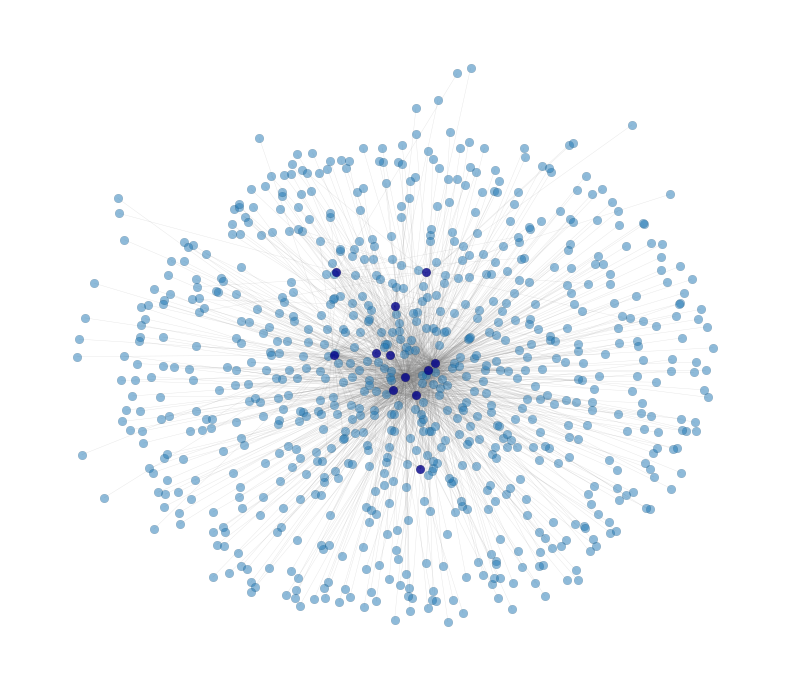


Red: soldado


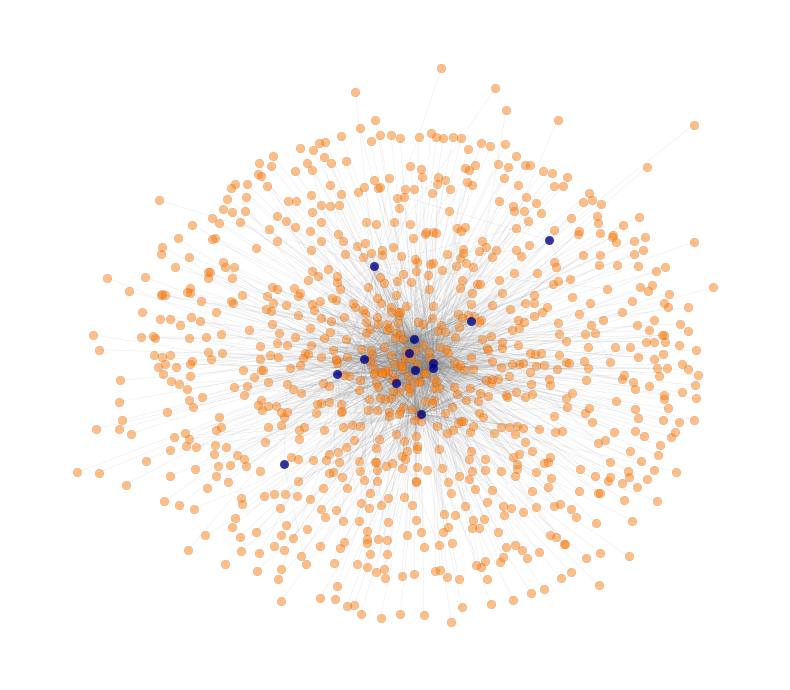


Red: mayor


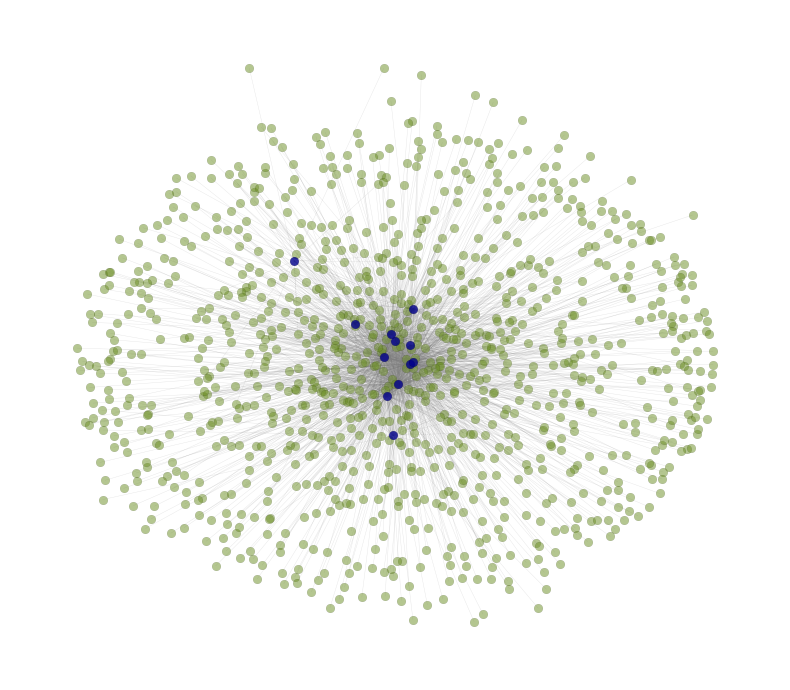


Red: teniente coronel


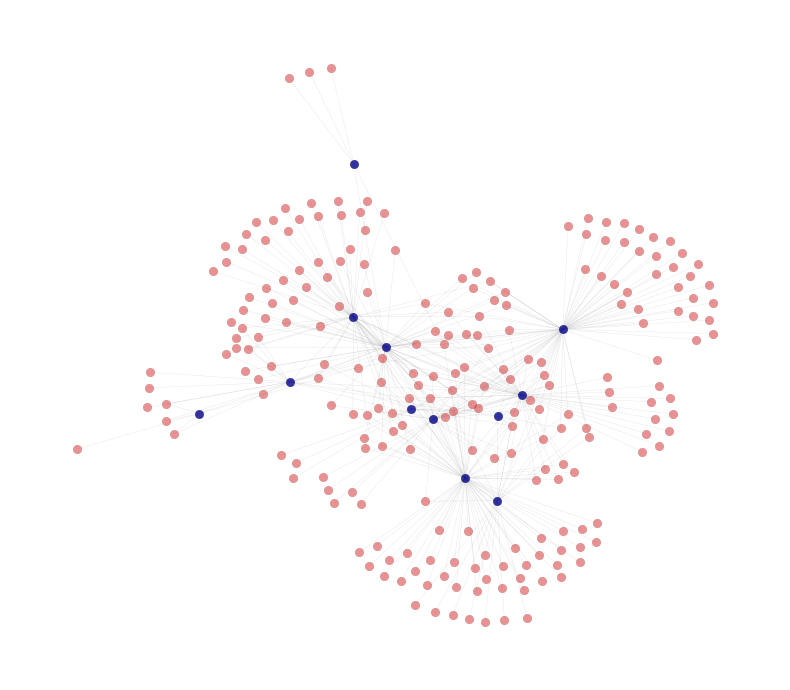


Red: capitan


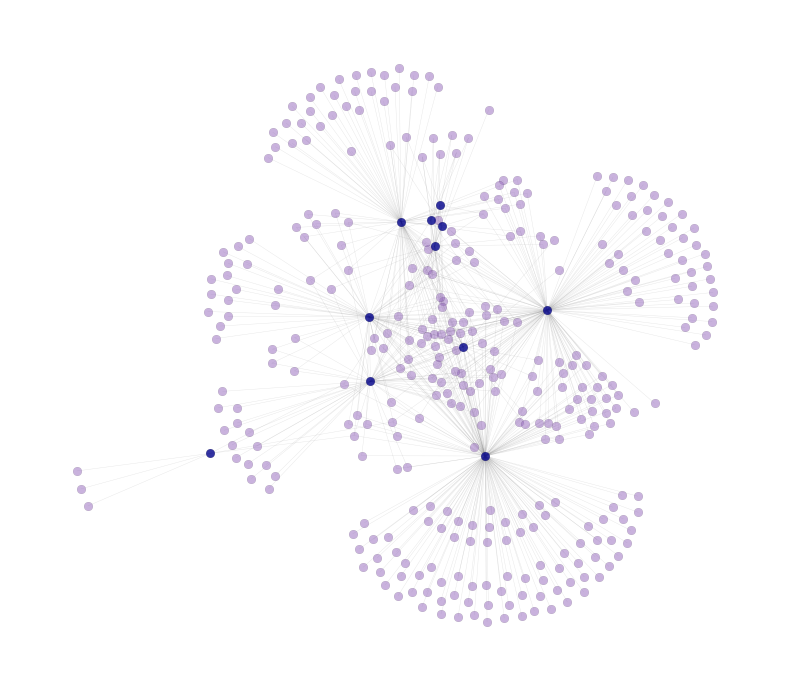


Red: subintendente jefe


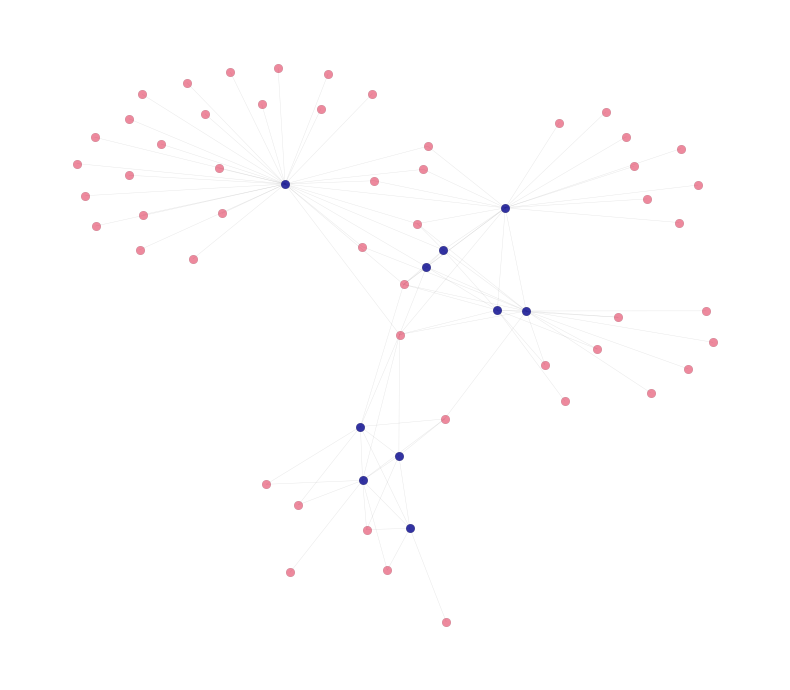


Red: coronel


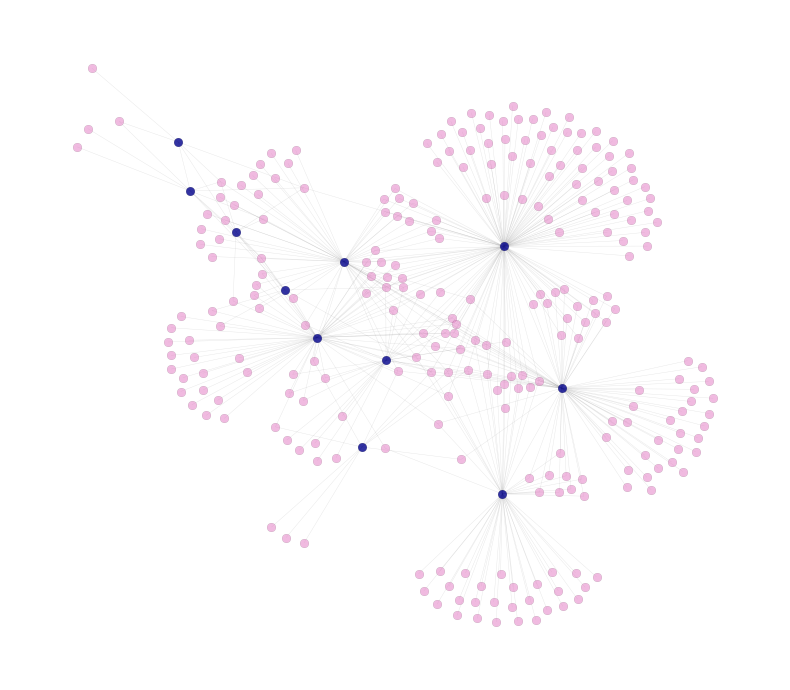

In [29]:
palette = [ "#1f77b4", "#ff7f0e", "olivedrab", "#d62728", "#9467bd", "crimson", "#e377c2", "#7f7f7f", "#bcbd22"]
for i, (nombre, G) in enumerate(subredes_por_texto.items()):

    print(f"\nRed: {nombre}")
    color_red = palette[i % len(palette)]
    plt.figure(figsize=(8, 7))

    pos = nx.spring_layout(G, seed=1234)
    grados = dict(G.degree())

    nodos_regiones = [n for n in G.nodes() if n in regiones]
    nodos_otros = [n for n in G.nodes() if n not in regiones]

    nx.draw_networkx_nodes(G, pos,nodelist=nodos_otros,node_size=40,node_color=color_red,alpha=0.5,edgecolors="black",linewidths=0.1)
    nx.draw_networkx_nodes(G, pos,nodelist=nodos_regiones,node_size=40,node_color="darkblue",alpha=0.8,edgecolors="black",linewidths=0.1)
    nx.draw_networkx_edges(G, pos,edge_color="gray",alpha=0.2,width=0.3)

    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [31]:
filas = []

for nombre_red, G in subredes_por_texto.items():

    grados = dict(G.degree())

    for nodo in G.nodes():
        if nodo in regiones:
            filas.append({
                "red": nombre_red,
                "region": nodo,
                "grado": grados[nodo]
            })
df_regiones_por_red = pd.DataFrame(filas)
df_regiones_por_red = df_regiones_por_red.sort_values(["red", "grado"], ascending=[True, False]).reset_index(drop=True)
df_regiones_por_red


,red,region,grado
0,capitan,carepa,182
1,capitan,mutata,148
2,capitan,turbo,85
3,capitan,apartado,74
4,capitan,dabeiba,57
...,...,...,...
76,teniente coronel,carmen_darien,19
77,teniente coronel,acandi,17
78,teniente coronel,unguia,8
79,teniente coronel,pedro_uraba,6
